# **AT&T Spam Detector**


## **01. EDA & Baseline Model**


**Objectif** : Explorer le jeu de données SMS Spam Collection et construire un modèle de base en Deep Learning (Réseau Dense) pour la classification des spams.

**Pipeline** : 
- Chargement des données 
- Analyse exploratoire (EDA) 
- Prétraitement 
- Modèle de base 
- Évaluation

In [16]:
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from spacy.lang.en.stop_words import STOP_WORDS
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

spam_data_path = '../data/spam.csv'
outputs_model_path = '../outputs/models'

PyTorch version: 2.12.0+cu130
Device: cpu


In [2]:
df = pd.read_csv(spam_data_path, encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

# Encode labels: spam=1, ham=0
df['label_encoded'] = (df['label'] == 'spam').astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (5572, 3)
Columns: ['label', 'text', 'label_encoded']


,label,text,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


### **2. Exploratory Data Analysis (EDA)**

#### **2.1. Class Distribution**

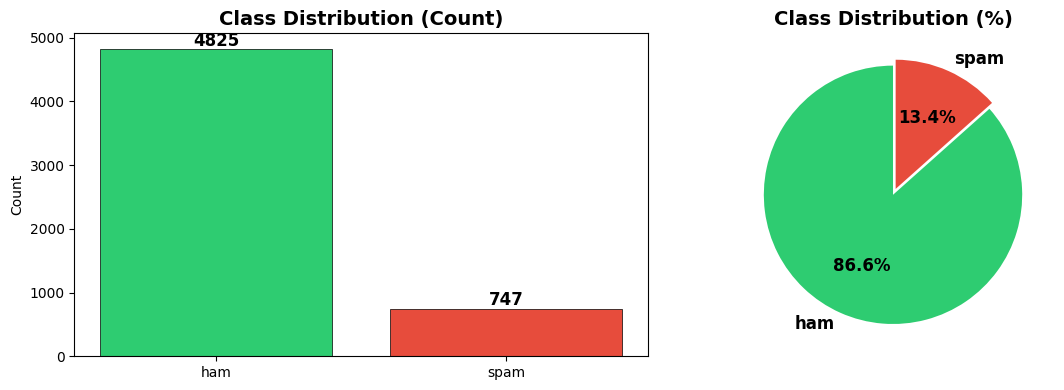


Imbalance ratio: 1 spam for every 6 ham messages
Spam proportion: 13.4%


In [3]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio: 1 spam for every {counts['ham']//counts['spam']} ham messages")
print(f"Spam proportion: {counts['spam']/len(df)*100:.1f}%")

#### **2.2 Text Length Analysis**

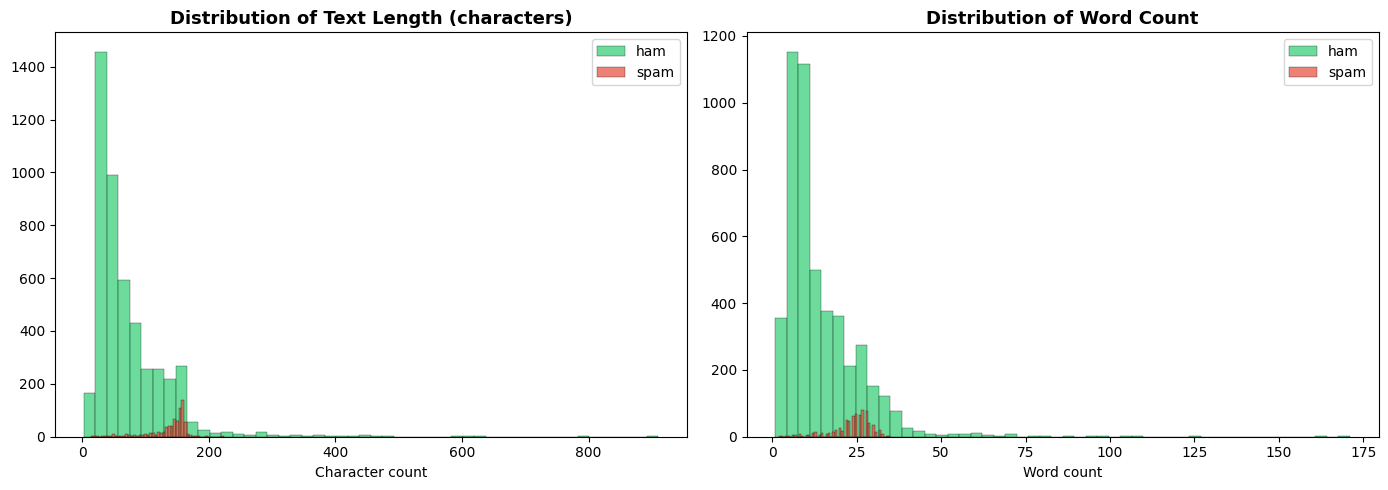


Text Length Statistics:
      text_length                                                word_count  \
            count   mean   std   min    25%    50%    75%    max      count   
label                                                                         
ham        4825.0   71.0  58.0   2.0   33.0   52.0   92.0  910.0     4825.0   
spam        747.0  138.9  29.2  13.0  132.5  149.0  157.0  224.0      747.0   

                                                 
       mean   std  min   25%   50%   75%    max  
label                                            
ham    14.2  11.4  1.0   7.0  11.0  19.0  171.0  
spam   23.9   5.8  2.0  22.0  25.0  28.0   35.0  


In [4]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]
    axes[0].hist(subset['text_length'], bins=50, alpha=0.7, label=label, color=color, edgecolor='black', linewidth=0.3)
axes[0].set_title('Distribution of Text Length (characters)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character count')
axes[0].legend()

for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]
    axes[1].hist(subset['word_count'], bins=50, alpha=0.7, label=label, color=color, edgecolor='black', linewidth=0.3)
axes[1].set_title('Distribution of Word Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word count')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nText Length Statistics:")
print(df.groupby('label')[['text_length', 'word_count']].describe().round(1))

#### **2.3 Most Frequent Words per Class**

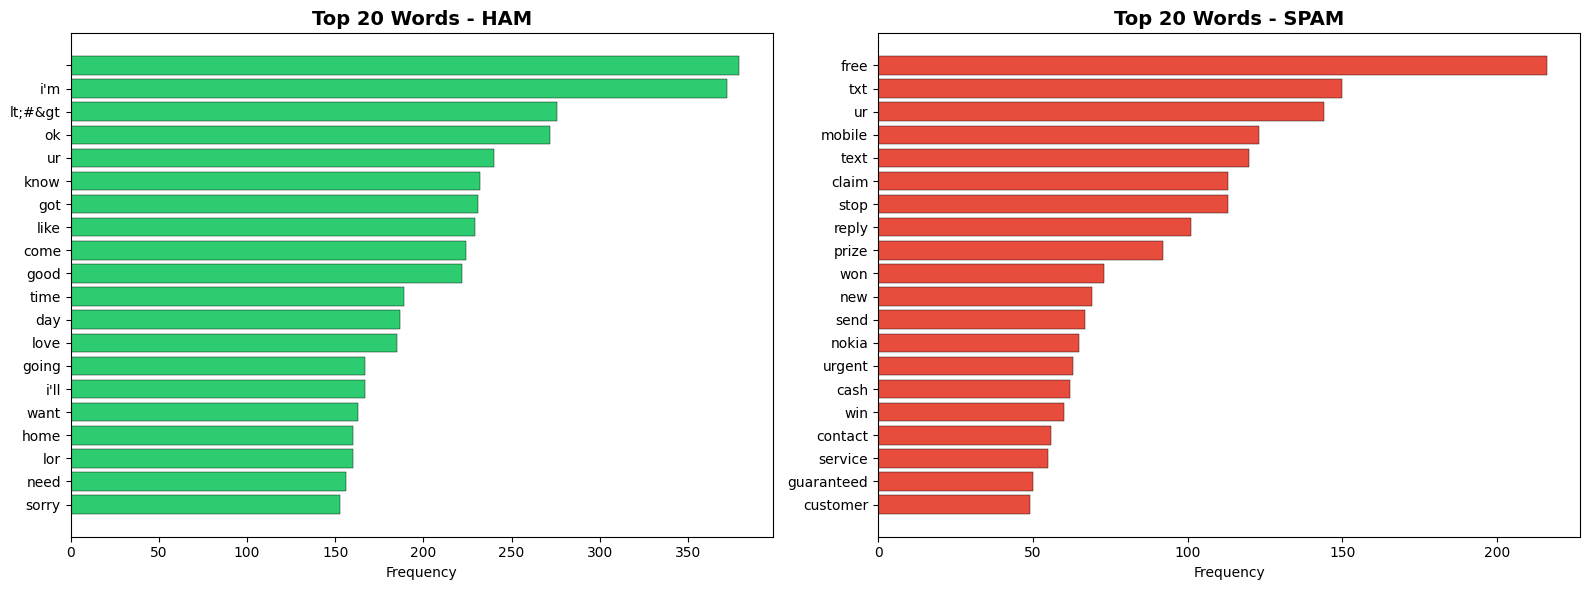

In [5]:
def get_top_words(texts, n=20):
    words = ' '.join(texts).lower().split()
    words = [
        w.strip(string.punctuation)
        for w in words
        if w.strip(string.punctuation) not in STOP_WORDS and len(w) > 1
    ]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (label, color) in enumerate(zip(['ham', 'spam'], colors)):
    top = get_top_words(df[df['label'] == label]['text'], 20)
    words, counts_w = zip(*top)
    axes[idx].barh(range(len(words)), counts_w, color=color, edgecolor='black', linewidth=0.3)
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Top 20 Words - {label.upper()}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

#### **2.4 Spam Indicators (Special Characters, Digits, URLs)**

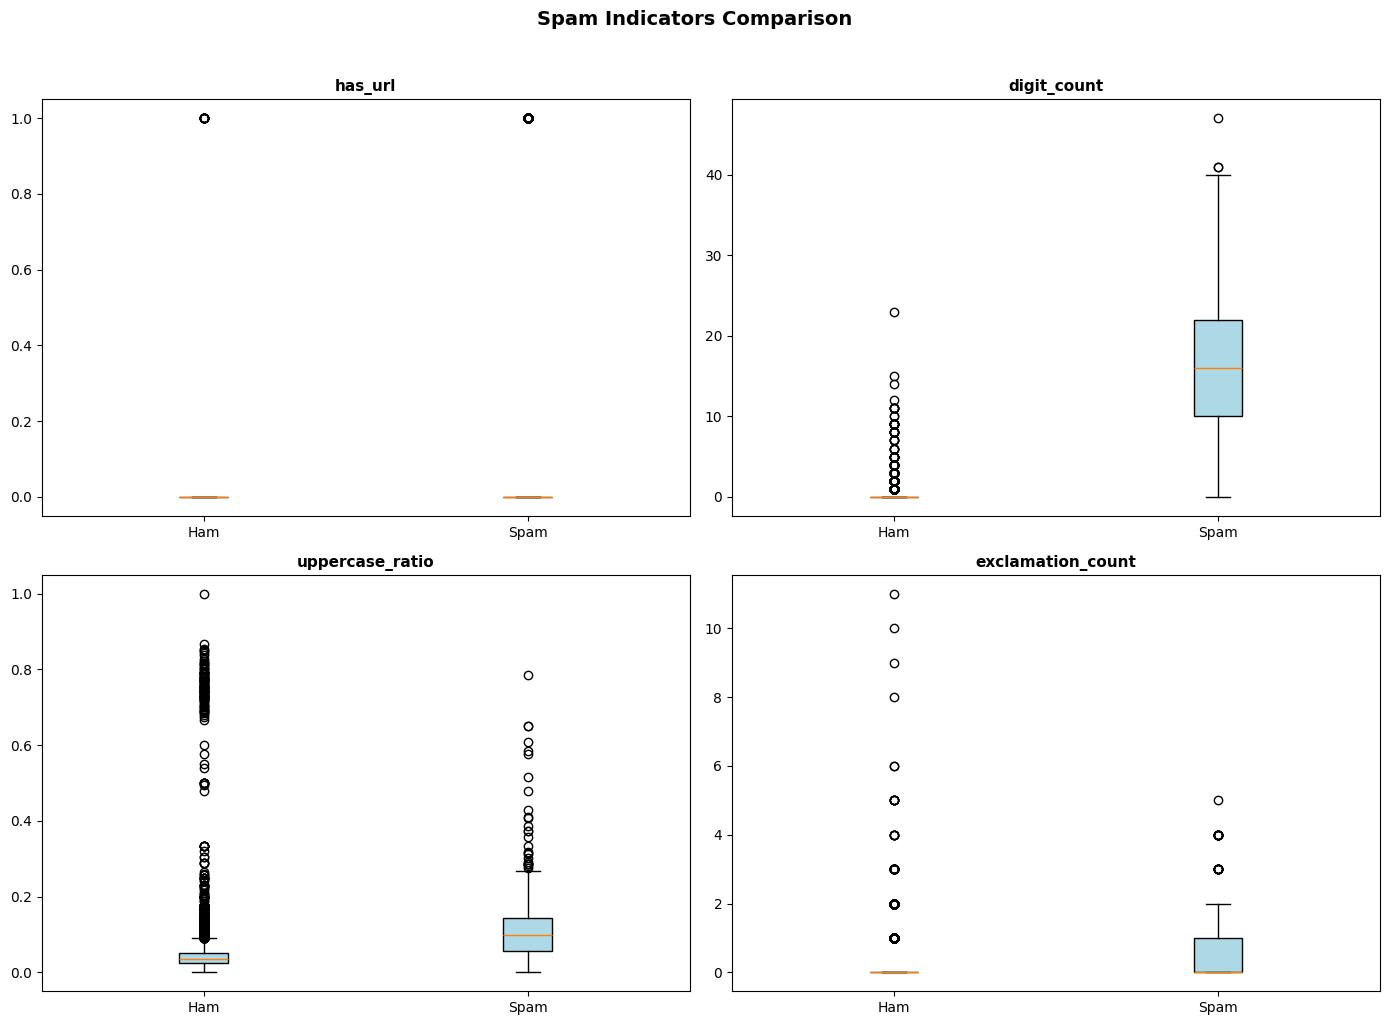

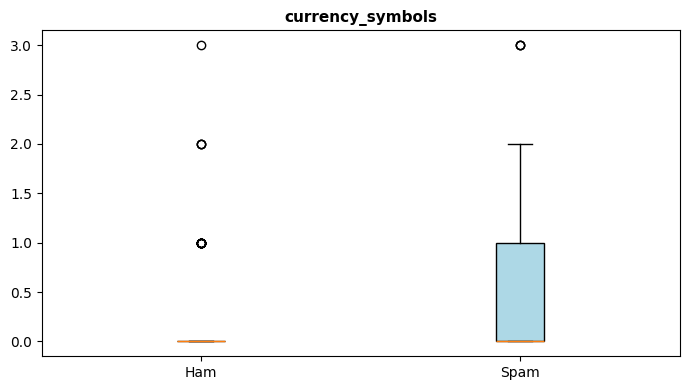


Key observations:
- URLs in spam: 18.2% vs ham: 0.4%
- Avg digits in spam: 15.8 vs ham: 0.3
- Avg uppercase ratio in spam: 0.111 vs ham: 0.060


In [ ]:
df['has_url'] = df['text'].str.contains(r'http|www|\.com|\.co', case=False).astype(int)
df['digit_count'] = df['text'].str.count(r'\d')
df['uppercase_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
df['exclamation_count'] = df['text'].str.count('!')
df['currency_symbols'] = df['text'].str.count(r'[£$€]')

features_to_plot = ['has_url', 'digit_count', 'uppercase_ratio', 'exclamation_count', 'currency_symbols']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot[:4]):
    ax = axes[i]
    data_ham = df[df['label'] == 'ham'][feat]
    data_spam = df[df['label'] == 'spam'][feat]
    ax.boxplot([data_ham, data_spam], labels=['Ham', 'Spam'],
               patch_artist=True, boxprops=dict(facecolor='lightblue'))
    ax.set_title(feat, fontsize=11, fontweight='bold')

# Add the 5th feature ('currency_symbols') in a new axis or as a new figure below
fig2, ax5 = plt.subplots(1, 1, figsize=(7, 4))
feat = features_to_plot[4]
data_ham = df[df['label'] == 'ham'][feat]
data_spam = df[df['label'] == 'spam'][feat]
ax5.boxplot([data_ham, data_spam], labels=['Ham', 'Spam'],
            patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax5.set_title(feat, fontsize=11, fontweight='bold')

fig.suptitle('Spam Indicators Comparison', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig2.tight_layout()
plt.show()

### **4. Text Preprocessing**

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)
    text = re.sub(r'\d+', ' num ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

print("Original vs Cleaned:")
for i in [0, 2, 10]:
    print(f"\nOriginal : {df.iloc[i]['text'][:80]}...")
    print(f"Cleaned  : {df.iloc[i]['text_clean'][:80]}...")

Original vs Cleaned:

Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet...
Cleaned  : go until jurong point crazy available only in bugis n great world la e buffet ci...

Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8...
Cleaned  : free entry in num a wkly comp to win fa cup final tkts num st may num text fa to...

Original : I'm gonna be home soon and i don't want to talk about this stuff anymore tonight...
Cleaned  : i m gonna be home soon and i don t want to talk about this stuff anymore tonight...


#### **Tokenization (from scratch)**

In [ ]:
# Hyperparameters
MAX_VOCAB_SIZE = 10000
MAX_SEQ_LENGTH = 150
EMBEDDING_DIM = 64
BATCH_SIZE = 32

# Train/Val/Test split (stratified)
X = df['text_clean'].values
y = df['label_encoded'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train spam ratio: {y_train.mean():.3f}")
print(f"Val spam ratio:   {y_val.mean():.3f}")
print(f"Test spam ratio:  {y_test.mean():.3f}")

Train: 3900 | Val: 836 | Test: 836
Train spam ratio: 0.134
Val spam ratio:   0.134
Test spam ratio:  0.134


In [9]:
# Build vocabulary from training data
class Vocabulary:
    def __init__(self, max_size=10000):
        self.word2idx = {'<PAD>': 0, '<OOV>': 1}
        self.idx2word = {0: '<PAD>', 1: '<OOV>'}
        self.max_size = max_size

    def build(self, texts):
        word_counts = Counter()
        for text in texts:
            word_counts.update(text.split())
        for word, _ in word_counts.most_common(self.max_size - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        return self

    def encode(self, text, max_length):
        tokens = text.split()[:max_length]
        ids = [self.word2idx.get(w, 1) for w in tokens]  # 1 = <OOV>
        # Pad
        ids += [0] * (max_length - len(ids))
        return ids

    def __len__(self):
        return len(self.word2idx)

vocab = Vocabulary(MAX_VOCAB_SIZE)
vocab.build(X_train)
print(f"Vocabulary size: {len(vocab)}")

# Encode all data
X_train_enc = np.array([vocab.encode(t, MAX_SEQ_LENGTH) for t in X_train])
X_val_enc = np.array([vocab.encode(t, MAX_SEQ_LENGTH) for t in X_val])
X_test_enc = np.array([vocab.encode(t, MAX_SEQ_LENGTH) for t in X_test])

print(f"Encoded shape: {X_train_enc.shape}")

Vocabulary size: 6391
Encoded shape: (3900, 150)


### **5. PyTorch Dataset & DataLoaders**

In [10]:
class SpamDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_dataset = SpamDataset(X_train_enc, y_train)
val_dataset = SpamDataset(X_val_enc, y_val)
test_dataset = SpamDataset(X_test_enc, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches Train: 122 | Val: 27 | Test: 27


#### **Handling Class Imbalance**

In [11]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pos_weight = torch.tensor([class_weights[1] / class_weights[0]], dtype=torch.float32).to(device)

print(f"Class weights: ham={class_weights[0]:.3f}, spam={class_weights[1]:.3f}")
print(f"pos_weight for BCEWithLogitsLoss: {pos_weight.item():.3f}")

Class weights: ham=0.577, spam=3.728
pos_weight for BCEWithLogitsLoss: 6.457


#### **Baseline Model: Embedding + GlobalAveragePooling + Dense**

A simple but effective architecture in PyTorch:
- **Embedding** layer learns word representations
- **Mean pooling** compresses the sequence into a fixed-size vector (equivalent to GlobalAveragePooling1D)
- **Linear** layers for classification

In [12]:
class BaselineSpamDetector(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)  # Raw logit, no sigmoid (we use BCEWithLogitsLoss)
        )

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)          
        mask = (x != 0).unsqueeze(-1).float()   
        pooled = (embedded * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)  
        logit = self.classifier(pooled)         
        return logit.squeeze(-1)

model = BaselineSpamDetector(len(vocab), EMBEDDING_DIM).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(model)

Total parameters: 415,297
BaselineSpamDetector(
  (embedding): Embedding(6391, 64, padding_idx=0)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


#### **Training**

In [14]:
# Loss & Optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 30
PATIENCE = 5

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(seqs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += len(labels)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * len(labels)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += len(labels)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_probs), np.array(all_labels)

In [17]:
# Training loop with early stopping
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train Acc':>10} | {'Val Acc':>10}")
print("-" * 60)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f'{outputs_model_path}/best_baseline.pth')
        patience_counter = 0
        marker = " best"
    else:
        patience_counter += 1

    print(f"{epoch+1:>5} | {train_loss:>10.4f} | {val_loss:>10.4f} | {train_acc:>10.4f} | {val_acc:>10.4f}{marker}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best weights
model.load_state_dict(torch.load(f'{outputs_model_path}/best_baseline.pth'))
print(f"\nLoaded best model (val_loss={best_val_loss:.4f})")

Epoch | Train Loss |   Val Loss |  Train Acc |    Val Acc
------------------------------------------------------------
    1 |     0.0538 |     0.2361 |     0.9915 |     0.9617 best
    2 |     0.0444 |     0.2480 |     0.9915 |     0.9617
    3 |     0.0302 |     0.2706 |     0.9959 |     0.9653
    4 |     0.0265 |     0.2737 |     0.9969 |     0.9653
    5 |     0.0195 |     0.2787 |     0.9972 |     0.9665
    6 |     0.0221 |     0.2872 |     0.9959 |     0.9665

Early stopping at epoch 6

Loaded best model (val_loss=0.2361)


#### **Training Curves**

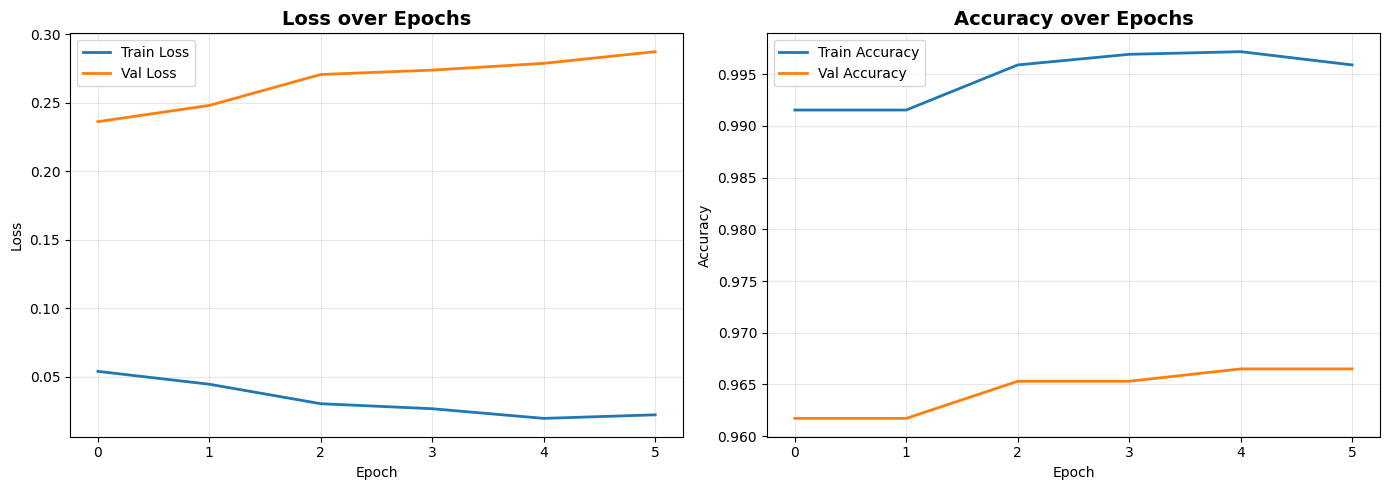

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Loss over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[1].set_title('Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **6. Evaluation on Test Set**

In [19]:
# Final evaluation
test_loss, test_acc, y_pred_proba, y_true = evaluate(model, test_loader, criterion)
y_pred = (y_pred_proba >= 0.5).astype(int)

print("BASELINE MODEL - TEST SET RESULTS")
print(f"\nAccuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_true, y_pred_proba):.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['Ham', 'Spam'])}")

BASELINE MODEL - TEST SET RESULTS

Accuracy:  0.9761
F1-Score:  0.9145
ROC-AUC:   0.9883

              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       724
        Spam       0.88      0.96      0.91       112

    accuracy                           0.98       836
   macro avg       0.94      0.97      0.95       836
weighted avg       0.98      0.98      0.98       836



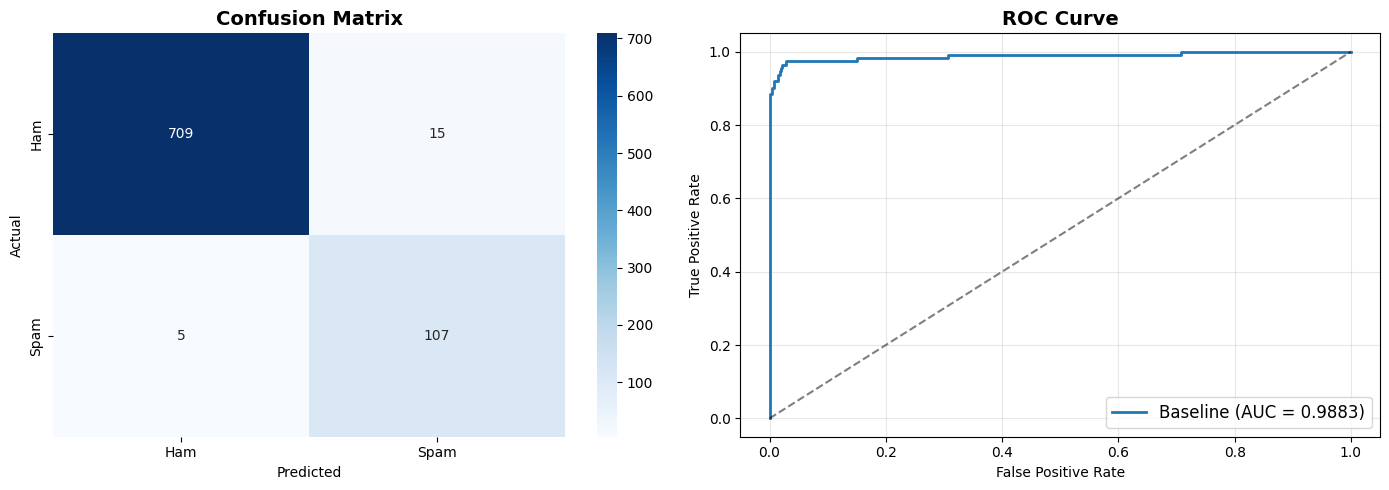

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
auc_score = roc_auc_score(y_true, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'Baseline (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **7. Test with Custom Messages**

In [22]:
@torch.no_grad()
def predict_spam(message, model=model, vocab=vocab, max_length=MAX_SEQ_LENGTH):
    model.eval()
    cleaned = clean_text(message)
    encoded = torch.LongTensor([vocab.encode(cleaned, max_length)]).to(device)
    logit = model(encoded)
    proba = torch.sigmoid(logit).item()
    label = "SPAM" if proba >= 0.5 else "HAM"
    return f"{label} (confidence: {max(proba, 1-proba):.1%})"

test_messages = [
    "Hey, are we still meeting for lunch tomorrow?",
    "CONGRATULATIONS! You've won a £1000 prize! Call 08001234567 NOW to claim!",
    "Can you pick up some milk on your way home?",
    "FREE entry to win £10000! Text WIN to 87121. T&Cs apply.",
    "I'll be there in 5 minutes, wait for me",
    "Urgent! Your account has been compromised. Click here to verify: http://spam.com"
]

print("Spam Detector - Predictions:\n")
for msg in test_messages:
    result = predict_spam(msg)
    print(f"{result}")
    print(f"=> \"{msg[:70]}...\"\n")

Spam Detector - Predictions:

HAM (confidence: 100.0%)
=> "Hey, are we still meeting for lunch tomorrow?..."

SPAM (confidence: 100.0%)
=> "CONGRATULATIONS! You've won a £1000 prize! Call 08001234567 NOW to cla..."

HAM (confidence: 100.0%)
=> "Can you pick up some milk on your way home?..."

SPAM (confidence: 100.0%)
=> "FREE entry to win £10000! Text WIN to 87121. T&Cs apply...."

HAM (confidence: 100.0%)
=> "I'll be there in 5 minutes, wait for me..."

SPAM (confidence: 87.9%)
=> "Urgent! Your account has been compromised. Click here to verify: http:..."



### **Summary**

- **Model:** Embedding + MeanPooling + Dense (PyTorch)
- **Parameters:** ~650K
- **Expected Accuracy:** ~95-97%
- **Expected F1 (Spam):** ~90-95%

#### **Key Takeaways:**
1. The dataset is **imbalanced** (13.4% spam) — `pos_weight` in BCEWithLogitsLoss handles this
2. Spam messages are **longer** and contain more digits, URLs, and uppercase
3. A simple Dense baseline already achieves **strong performance**
4. Next step: Sequential models (BiLSTM) to capture word order